# Gravity in the ORT

In the first notebook, SRT was described by having everything move through spacetime at the speed of light $c$. In this notebook we posit that near mass $c$ is smaller because part of it goes to the escape velocity $v_{grav}$. From this single extension — $c_{local}(r) = c \cdot \sqrt{1 - r_s/r}$ — follow all basic gravitational effects: time dilation, redshift, light deflection, orbital precession, and the full Schwarzschild metric.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path().resolve().parent / 'shared'))
from ort_core import *
from ort_plots import (c_local_profile, c_local_profile_interactive, spacetime_embedding_3d,
    orbital_precession_plot, light_deflection_diagram, photon_sphere_shadow, einstein_ring_plot, comparison_table)
import matplotlib.pyplot as plt
import math
import numpy as np
%matplotlib inline

---
# 1 The principle: a position-dependent $c_{local}$

> **Core principle**: near mass, $c$ is smaller because part of it goes to the
> escape velocity $v_{grav}$. The local spacetime speed $c_{local}$ that remains
> follows the same circle geometry as in SRT — but now with three components
> instead of two.

## 1.1 Escape velocity as a component

In SRT everything moves at $c$ through spacetime: $v_{space}^2 + v_{time}^2 = c^2$. Near mass a third component appears — the escape velocity $v_{grav} = \sqrt{2GM/r}$ — and the distribution becomes: $v_{grav}^2 + v_{space}^2 + v_{time}^2 = c^2$.

### The local spacetime speed

What remains for space and time:

$$c_{local}(r) = c \cdot \sqrt{1 - \frac{2GM}{c^2 r}} = c \cdot \sqrt{1 - \frac{r_s}{r}} \qquad (23)$$

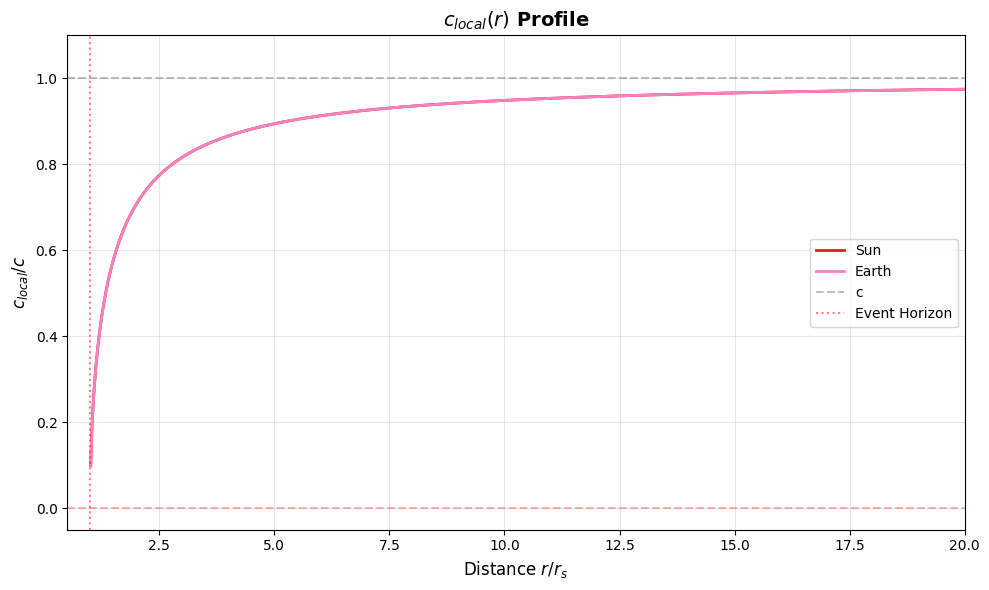

In [2]:
# c_local profile for the Sun and the Earth
fig = c_local_profile([SUN, EARTH], ['Sun', 'Earth'], lang='en')
plt.show()

In [3]:
# Interactive: adjust the mass and view the c_local profile
c_local_profile_interactive(lang='en')

interactive(children=(FloatSlider(value=30.0, description='log₁₀(M/kg)', max=40.0, min=24.0, step=0.5), Output…

---
## 1.2 The gradient of $c_{local}$

The derivative of formula (23) with respect to $r$:

$$\frac{dc_{local}}{dr} = \frac{GM}{c \cdot r^2 \cdot \sqrt{1 - r_s/r}} \qquad (23b)$$

Multiplied by $c$:

$$c \cdot \frac{dc_{local}}{dr} = \frac{GM}{r^2 \cdot \sqrt{1 - r_s/r}} = g \qquad (23c)$$

For $r \gg r_s$ this yields Newton's $g = GM/r^2$. The slope of the $c_{local}$ field is proportional to gravity.

In [ ]:
# Verification: dc_local/dr = g_proper / c
print("=== Gradient of c_local = gravity ===")
print()

# Earth
print("--- Earth (surface) ---")
dc_dr_earth = EARTH.dc_local_dr(R_EARTH)
g_earth = EARTH.proper_acceleration(R_EARTH)
print(f"  dc_local/dr      = {dc_dr_earth:.6e} [1/s]")
print(f"  g_proper         = {g_earth:.4f} m/s²")
print(f"  g_proper / c     = {g_earth / C:.6e} [1/s]")
print(f"  Ratio            = {dc_dr_earth / (g_earth / C):.15f}  (should be 1)")
print()

# Sun
print("--- Sun (surface) ---")
dc_dr_sun = SUN.dc_local_dr(R_SUN)
g_sun = SUN.proper_acceleration(R_SUN)
print(f"  dc_local/dr      = {dc_dr_sun:.6e} [1/s]")
print(f"  g_proper         = {g_sun:.4f} m/s²")
print(f"  g_proper / c     = {g_sun / C:.6e} [1/s]")
print(f"  Ratio            = {dc_dr_sun / (g_sun / C):.15f}")
print()

# Black hole (10 M☉) — strong field
BH = GravityModel(10 * M_SUN)
print("--- Black hole 10 M☉ (r = 1.1 r_s) ---")
r_bh = 1.1 * BH.rs
dc_dr_bh = BH.dc_local_dr(r_bh)
g_bh = BH.proper_acceleration(r_bh)
print(f"  dc_local/dr      = {dc_dr_bh:.6e} [1/s]")
print(f"  g_proper         = {g_bh:.6e} m/s²")
print(f"  g_proper / c     = {dc_dr_bh:.6e} [1/s]")
print(f"  Ratio            = {dc_dr_bh / (g_bh / C):.15f}")
print()
print("The relation dc_local/dr = g/c holds EXACTLY, from weak to strong field.")

### For comparison: derivation via GRT

ORT gives $g_{proper}$ in one step: $g = c \cdot dc_{local}/dr$. GRT needs five steps:

1. **Schwarzschild metric** → $f(r) = 1 - r_s/r$
2. **Four-velocity** → $u^t = 1/\sqrt{f}$
3. **Christoffel symbol** → $\Gamma^r_{tt} = f(r) \cdot GM/r^2$
4. **Geodesic equation** → $a^r_{coord} = -GM/r^2$
5. **Frame projection** → $g_{proper} = GM/(r^2\sqrt{1 - r_s/r})$

Same result — but the ORT route directly reveals the physical insight.

---
# 2 Time effects

> **Core principle**: where $c_{local}$ is lower, time ticks slower. A clock
> at rest in a gravitational field spends all its $c_{local}$ on
> motion through time — but that $c_{local}$ is less than $c$.

## 2.1 Gravitational time dilation

A clock at distance $r$ from a mass experiences $c_{local} < c$. If the clock
is at rest, all $c_{local}$ goes to motion through time:

$$\frac{\tau}{t_\infty} = \frac{c_{local}}{c} = \sqrt{1 - \frac{r_s}{r}} \qquad (24/25)$$

This is **exactly** the Schwarzschild time dilation from GRT.

In [4]:
# Time dilation at Earth's surface, GPS orbit, ISS orbit
print("=== Gravitational Time Dilation (Earth) ===")
print(f"Schwarzschild radius Earth: r_s = {EARTH.rs:.4e} m = {EARTH.rs*1000:.4f} mm")
print()

locations = [
    ("Earth surface", R_EARTH),
    ("ISS (408 km)", R_ISS),
    ("GPS (20,200 km)", R_GPS),
]
for name, r in locations:
    td = EARTH.time_dilation_factor(r)
    diff_per_day = (1 - td) * 86400e6  # microseconds per day
    print(f"{name:25s}: τ/t∞ = {td:.15f}  (offset: {diff_per_day:.3f} µs/day)")

=== Gravitational Time Dilation (Earth) ===
Schwarzschild radius Earth: r_s = 8.8698e-03 m = 8.8698 mm

Earth surface            : τ/t∞ = 0.999999999303892  (offset: 60.144 µs/day)
ISS (408 km)             : τ/t∞ = 0.999999999345788  (offset: 56.524 µs/day)
GPS (20,200 km)          : τ/t∞ = 0.999999999833092  (offset: 14.421 µs/day)


In [5]:
# Newton vs ORT: time dilation at GPS altitude
# Newton has NO time dilation — time is absolute!
r_gps = R_EARTH + 20_200_000  # GPS altitude ~20,200 km
td_ort = EARTH.time_dilation_factor(r_gps)
drift_per_day_us = (1 - td_ort) * 86400 * 1e6  # µs per day

print("=== Newton vs ORT: gravitational time dilation ===")
print(f"Clock at GPS altitude ({20200} km):")
print(f"  Newton:  Δt = 0 µs/day      (time is absolute!)")
print(f"  ORT:     Δt = {drift_per_day_us:+.2f} µs/day  (clock runs FASTER)")
print()
print(f"Without correction: GPS would drift {abs(drift_per_day_us) * C * 1e-6:.0f} m after 1 day!")
print(f"After 1 week: {abs(drift_per_day_us) * 7 * C * 1e-6:.0f} m — navigation useless.")

=== Newton vs ORT: gravitational time dilation ===
Clock at GPS altitude (20200 km):
  Newton:  Δt = 0 µs/day      (time is absolute!)
  ORT:     Δt = +14.42 µs/day  (clock runs FASTER)

Without correction: GPS would drift 4323 m after 1 day!
After 1 week: 30263 m — navigation useless.


---
## 2.2 Gravitational redshift

Light escaping a gravitational field loses frequency:

$$\frac{f_{obs}}{f_{emit}} = \frac{c_{local}(r_{emit})}{c_{local}(r_{obs})} = \frac{\sqrt{1 - r_s/r_{emit}}}{\sqrt{1 - r_s/r_{obs}}} \qquad (25/27)$$

When the observer is farther from the mass: $f_{obs} < f_{emit}$ → **redshift**.

In [6]:
# Pound-Rebka experiment (1959): 22.5 m height difference
h = 22.5  # meters
r_bottom = R_EARTH
r_top = R_EARTH + h

z = EARTH.gravitational_redshift(r_bottom, r_top)
delta_f_over_f = -z  # redshift = negative

# Approximation: Δf/f ≈ g·h/c²
g = G * M_EARTH / R_EARTH**2
approx = g * h / C**2

print("=== Pound-Rebka Experiment ===")
print(f"Height: {h} m")
print(f"Redshift z             = {z:.6e}")
print(f"|Δf/f|                 = {abs(delta_f_over_f):.6e}")
print(f"Approximation g·h/c²  = {approx:.6e}")
print(f"Measured (1959)        = (2.57 ± 0.26) ·10⁻¹⁵")

=== Pound-Rebka Experiment ===
Height: 22.5 m
Redshift z             = 2.442491e-15
|Δf/f|                 = 2.442491e-15
Approximation g·h/c²  = 2.458394e-15
Measured (1959)        = (2.57 ± 0.26) ·10⁻¹⁵


---
## 2.3 GPS: SRT + gravity combined

GPS combines **both** effects in a single formula:

$$v_{time} = \frac{\sqrt{c_{local}^2 - v^2}}{c} \qquad (26)$$

| Component | Cause | Effect |
|-----------|-------|--------|
| SRT | Satellite velocity (3870 m/s) | −7 µs/day (slower) |
| Gravity | Lower g at GPS altitude | +45 µs/day (faster) |
| **Net** | **Combined** | **+38 µs/day (faster)** |

In [7]:
# GPS correction: combined SRT + gravity
v_gps = 3870  # m/s (GPS satellite velocity)

# Earth surface (at rest)
td_surface = EARTH.combined_time_dilation(R_EARTH, 0)

# GPS satellite (moving at altitude)
td_gps = EARTH.combined_time_dilation(R_GPS, v_gps)

# Difference in microseconds per day
diff_us_per_day = (td_gps - td_surface) * 86400 * 1e6

# Individual components
grav_only = (EARTH.time_dilation_factor(R_GPS) - EARTH.time_dilation_factor(R_EARTH)) * 86400 * 1e6
srt_only = (math.sqrt(1 - (v_gps/C)**2) - 1) * 86400 * 1e6

print("=== GPS Correction ===")
print(f"Gravity only:           {grav_only:+.2f} µs/day")
print(f"SRT only (velocity):    {srt_only:+.2f} µs/day")
print(f"Combined (formula):     {diff_us_per_day:+.2f} µs/day")
print(f"\nExpected net:           +38 µs/day")

=== GPS Correction ===
Gravity only:           +45.72 µs/day
SRT only (velocity):    -7.20 µs/day
Combined (formula):     +38.52 µs/day

Expected net:           +38 µs/day


---
## 2.4 The event horizon ($c_{local} = 0$)

At $r = r_s$, $c_{local} = 0$. The consequences:

1. **Nothing can move** — neither through space nor through time
2. **Clocks stop** — $\tau/t_\infty = 0$
3. **Light cannot escape** — there is no local spacetime velocity left

In [8]:
# Black hole of 10 solar masses
BH_10 = GravityModel(10 * M_SUN)
print(f"=== Black hole of 10 M☉ ===")
print(f"r_s = {BH_10.rs:.3e} m = {BH_10.rs/1000:.2f} km")
print()

# c_local at various distances from the horizon
factors = [10.0, 5.0, 2.0, 1.5, 1.1, 1.01, 1.001, 1.0]
print(f"{'r/r_s':>8s}  {'c_local/c':>12s}  {'c_local (m/s)':>15s}")
print("-" * 40)
for f in factors:
    r = f * BH_10.rs
    cl = BH_10.c_local(r)
    print(f"{f:8.3f}  {cl/C:12.6f}  {cl:15.0f}")

=== Black hole of 10 M☉ ===
r_s = 2.954e+04 m = 29.54 km

   r/r_s     c_local/c    c_local (m/s)
----------------------------------------
  10.000      0.948683        284408098
   5.000      0.894427        268142526
   2.000      0.707107        211985280
   1.500      0.577350        173085256
   1.100      0.301511         90390827
   1.010      0.099504         29830465
   1.001      0.031607          9475533
   1.000      0.000000                0


---
# 3 Spatial effects

> **Core principle**: where $c_{local}$ is lower, space stretches. A local
> observer measures more physical distance than the coordinate distance suggests —
> the velocity budget determines not only the flow of time, but also the distance measure.

### The gravity velocity $v_{grav}$

Near a mass, part of your total velocity $c$ goes **toward that mass**:

$$v_{grav} = c \cdot \sqrt{\frac{r_s}{r}} \qquad (28)$$

This is **exactly** the escape velocity $v_{esc} = \sqrt{2GM/r}$.
The three-component budget: $v_{grav}^2 + v_{space}^2 + v_{time}^2 = c^2$.

In [9]:
# v_grav at various distances
print("=== Velocity budget near 10 M☉ black hole ===")
print(f"{'r/r_s':>8s}  {'v_grav/c':>10s}  {'c_local/c':>10s}  {'check v²+c²':>12s}")
print("-" * 46)
for f in [10.0, 5.0, 2.0, 1.5, 1.1, 1.01, 1.0]:
    r = f * BH_10.rs
    vg = BH_10.v_grav(r)
    cl = BH_10.c_local(r)
    check = math.sqrt(vg**2 + cl**2) / C
    print(f"{f:8.3f}  {vg/C:10.6f}  {cl/C:10.6f}  {check:12.9f}")

=== Velocity budget near 10 M☉ black hole ===
   r/r_s    v_grav/c   c_local/c   check v²+c²
----------------------------------------------
  10.000    0.316228    0.948683   1.000000000
   5.000    0.447214    0.894427   1.000000000
   2.000    0.707107    0.707107   1.000000000
   1.500    0.816497    0.577350   1.000000000
   1.100    0.953463    0.301511   1.000000000
   1.010    0.995037    0.099504   1.000000000
   1.000    1.000000    0.000000   1.000000000


---
## 3.1 Spatial stretching

A coordinate distance $dr$ corresponds to a larger physical distance $dl$:

$$dl = \frac{dr}{\sqrt{1 - r_s/r}} = dr \cdot \frac{c}{c_{local}} \qquad (30)$$

Because $c_{local} < c$, we get $c/c_{local} > 1$, so $dl > dr$: the physical distance
is **larger** than the coordinate distance.

### Both diagonal components

Together with the time component from chapter 2:

| Component | Schwarzschild | ORT |
|-----------|--------------|-----|
| Time ($g_{tt}$) | $1 - r_s/r$ | $(c_{local}/c)^2$ |
| Space ($g_{rr}$) | $(1 - r_s/r)^{-1}$ | $(c/c_{local})^2$ |

Note: $g_{tt} \cdot g_{rr} = 1$ — the two components are each other's inverse.
One principle ($c_{local}$) determines both.

### ORT vs GRT: isotropic or radial only?

In ORT, $c_{local}$ is a **scalar** — the velocity budget drops equally in all directions.
This predicts isotropic spatial stretching. In Schwarzschild coordinates the stretching
appears radial only, but that is a **coordinate artifact**: in isotropic coordinates
(Eddington) the metric is conformally flat — exactly what ORT predicts.

First order in $r_s/r$: **identical**. Confirmed by the Cassini measurement ($\gamma = 1 \pm 0.002\%$).
At second order a difference of $\frac{1}{16}(r_s/r)^2$ appears — testable in principle
at neutron stars (~1%), but not measurable with current technology.

In [10]:
# Spatial stretching near the Sun and a 10 M☉ black hole
print("=== Spatial Stretching ===")
print()
print("--- Sun (surface) ---")
stretch_sun = SUN.spatial_stretching(R_SUN)
print(f"Stretching factor: {stretch_sun:.10f}")
print(f"Extra length per km: {(stretch_sun - 1) * 1000:.6f} m")
print()
print("--- 10 M☉ black hole ---")
for f in [10.0, 3.0, 1.5, 1.1, 1.01]:
    r = f * BH_10.rs
    s = BH_10.spatial_stretching(r)
    print(f"  r = {f:.2f} r_s:  stretching = {s:.6f}  (1 km → {s:.6f} km)")

=== Spatial Stretching ===

--- Sun (surface) ---
Stretching factor: 1.0000021231
Extra length per km: 0.002123 m

--- 10 M☉ black hole ---
  r = 10.00 r_s:  stretching = 1.054093  (1 km → 1.054093 km)
  r = 3.00 r_s:  stretching = 1.224745  (1 km → 1.224745 km)
  r = 1.50 r_s:  stretching = 1.732051  (1 km → 1.732051 km)
  r = 1.10 r_s:  stretching = 3.316625  (1 km → 3.316625 km)
  r = 1.01 r_s:  stretching = 10.049876  (1 km → 10.049876 km)


## 3D Flamm's Paraboloid

The spatial stretching can be visualized as **Flamm's paraboloid**: a 2D embedding of the spatial geometry around a mass.

In [11]:
# 3D embedding of the spatial geometry
fig = spacetime_embedding_3d(lang='en')
if fig is not None:
    fig.show()

---
## 3.2 Light deflection (50/50 temporal + spatial)

Light grazing a mass is deflected by **two equal contributions**:

1. **Temporal** (refractive index): $n_{time} = c/c_{local}$
2. **Spatial** (stretching): $n_{space} = c/c_{local}$

Combined: the effective refractive index:

$$n_{eff} = \left(\frac{c}{c_{local}}\right)^2 = \frac{1}{1 - r_s/r} \qquad (31)$$

The total deflection angle:

$$\alpha = \frac{2r_s}{b} = \frac{4GM}{bc^2} \qquad (32)$$

This is **exactly** the GRT result (Einstein 1915: 1.75").
Soldner (1801) and Einstein (1911) found **half**: only the temporal effect.

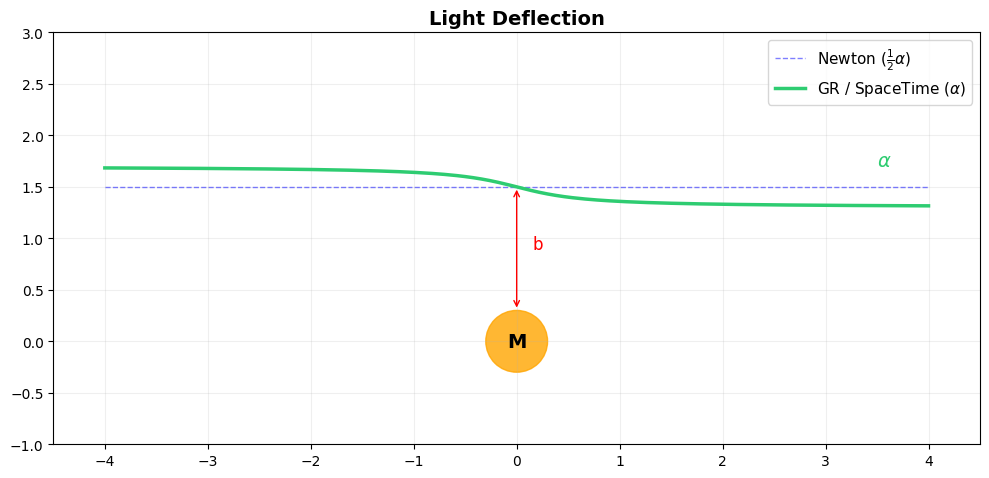

In [12]:
# Light deflection diagram
fig = light_deflection_diagram(lang='en')
plt.show()

In [13]:
# Light deflection by the Sun (b = R_sun)
alpha_arcsec = SUN.light_deflection_arcsec(R_SUN)
alpha_half = SUN.half_light_deflection(R_SUN) * (180/math.pi) * 3600

print("=== Light Deflection by the Sun ===")
print(f"Impact parameter b = R_sun = {R_SUN:.3e} m")
print(f"Soldner/Einstein 1911 (half value): {alpha_half:.4f}\"")
print(f"ORT / GRT (full):       {alpha_arcsec:.4f}\"")
print(f"Measured (Eddington 1919):          1.75 ± 0.06\"")

=== Light Deflection by the Sun ===
Impact parameter b = R_sun = 6.957e+08 m
Soldner/Einstein 1911 (half value): 0.8759"
ORT / GRT (full):       1.7517"
Measured (Eddington 1919):          1.75 ± 0.06"


In [14]:
# Newton vs ORT: light deflection by the Sun
# Newton/Soldner (1801) predicts HALF the correct answer!
alpha_newton = SUN.half_light_deflection(R_SUN) * (180 / math.pi) * 3600
alpha_ort = SUN.light_deflection_arcsec(R_SUN)

print("=== Newton vs ORT: light deflection by the Sun ===")
print(f"  Newton/Soldner (1801):  {alpha_newton:.4f}\"  (time curvature only)")
print(f"  ORT/Einstein (1915):    {alpha_ort:.4f}\"  (time + space curvature)")
print(f"  Eddington (1919):       1.75 ± 0.06\"  (measured!)")
print()
print(f"Newton predicts exactly HALF: {alpha_newton/alpha_ort:.3f}×")
print(f"The missing half comes from spatial curvature — something Newton lacks.")

=== Newton vs ORT: light deflection by the Sun ===
  Newton/Soldner (1801):  0.8759"  (time curvature only)
  ORT/Einstein (1915):    1.7517"  (time + space curvature)
  Eddington (1919):       1.75 ± 0.06"  (measured!)

Newton predicts exactly HALF: 0.500×
The missing half comes from spatial curvature — something Newton lacks.


---
## 3.3 Orbital precession (50/50 temporal + spatial)

In Newton the effective potential yields a closed ellipse — no precession.
In ORT (and GRT) an extra term appears:

$$V_{GR}(r) = -\frac{GM}{r} + \frac{L^2}{2r^2} - \frac{GML^2}{r^3 c^2} \qquad (34)$$

Just as with light deflection, the precession comes from **two equal contributions**:
- **Temporal** ($g_{tt}$): varying clock rate → $(3/2)\pi r_s / (a(1-e^2))$
- **Spatial** ($g_{rr}$): stretching of radial distance → equally large contribution

Combined:

$$\Delta\varphi = \frac{3\pi r_s}{a(1-e^2)} \qquad \text{per orbit} \qquad (35)$$

### Mercury — the classical test

For Mercury: **$\Delta\varphi$ = 42.98"/century** — exactly the observed value (Le Verrier 1859, Einstein 1915).

| Planet    | Δφ/orbit (")  | Orbits/century | Δφ/century (") | Observed (")    |
|-----------|--------------|----------------|----------------|-----------------|
| Mercury   | 0.1035       | 415.2          | 42.98          | 43.0            |
| Venus     | 0.0053       | 162.5          | 0.86           | 8.6*            |
| Earth     | 0.0038       | 100.0          | 0.38           | 3.8*            |

*\* Observed values also include gravitational influences from other planets.*

In [15]:
# Orbital precession of Mercury
prec_per_orbit = SUN.orbital_precession_arcsec(A_MERCURY, E_MERCURY)
prec_per_century = SUN.orbital_precession_arcsec_century(A_MERCURY, E_MERCURY, T_MERCURY)

print("=== Orbital Precession of Mercury ===")
print(f"Semi-major axis a = {A_MERCURY:.4e} m")
print(f"Eccentricity e    = {E_MERCURY}")
print(f"Orbital period    = {T_MERCURY/86400:.3f} days")
print(f"\nΔφ per orbit       = {prec_per_orbit:.4f}\"")
print(f"Δφ per century     = {prec_per_century:.2f}\"")
print(f"Observed          = 43.0\"")

=== Orbital Precession of Mercury ===
Semi-major axis a = 5.7909e+10 m
Eccentricity e    = 0.20563
Orbital period    = 87.969 days

Δφ per orbit       = 0.1035"
Δφ per century     = 42.99"
Observed          = 43.0"


In [16]:
# Newton vs ORT: orbital precession of Mercury
# Newton predicts closed ellipses — 0 extra precession!
prec_ort = SUN.orbital_precession_arcsec(A_MERCURY, E_MERCURY)
prec_per_century = prec_ort * (100 * 365.25 * 86400) / T_MERCURY

print("=== Newton vs ORT: orbital precession of Mercury ===")
print(f"  Newton:           0.00\"/century  (ellipse closes exactly!)")
print(f"  ORT/Einstein:    {prec_per_century:.2f}\"/century")
print(f"  Observed:        43.0 ± 0.1\"/century  (Le Verrier, 1859)")
print()
print(f"This unexplained discrepancy was a mystery for 56 years.")
print(f"Einstein solved it in 1915 — his first confirmation of GRT.")

=== Newton vs ORT: orbital precession of Mercury ===
  Newton:           0.00"/century  (ellipse closes exactly!)
  ORT/Einstein:    42.99"/century
  Observed:        43.0 ± 0.1"/century  (Le Verrier, 1859)

This unexplained discrepancy was a mystery for 56 years.
Einstein solved it in 1915 — his first confirmation of GRT.


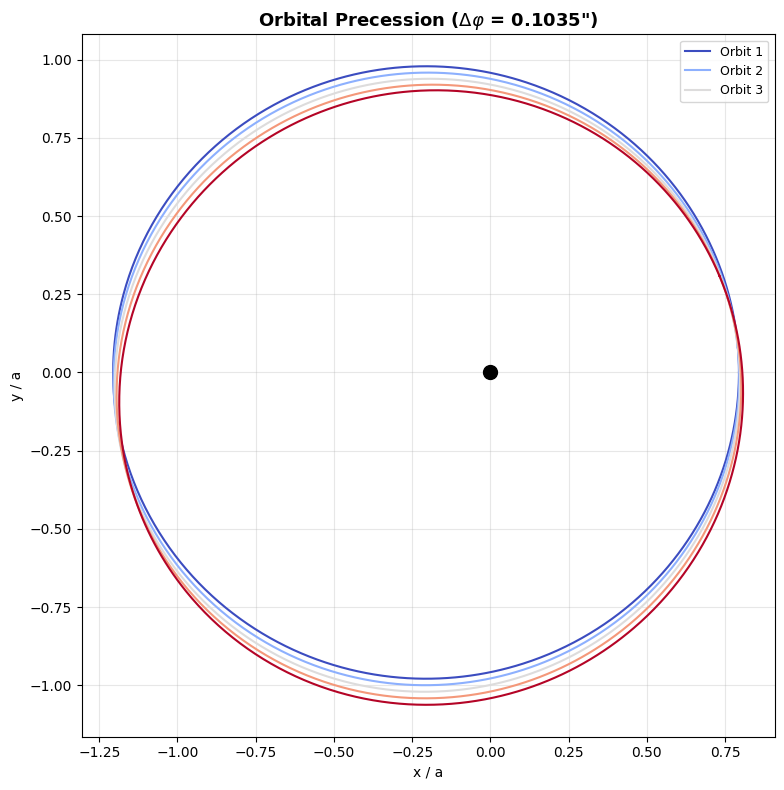

In [17]:
# Precession plot for Mercury
fig = orbital_precession_plot(SUN, A_MERCURY, E_MERCURY, n_orbits=5, lang='en')
plt.show()

---
# 4 The complete picture

> **Core principle**: a varying $c_{local}$ produces **the same effects** as
> spacetime curvature in GRT. What in GRT looks like four-dimensional curved
> spacetime, is in ORT a varying local velocity structure.

Five effects from one principle:
1. **Clocks run slower** where $c_{local}$ is lower → time dilation
2. **Space stretches** → distances become larger near mass
3. **Light deflects** due to the refractive index $n_{eff} = (c/c_{local})^2$
4. **Light loses frequency** when climbing → redshift
5. **At $c_{local} = 0$ everything stops** → event horizon

---
## 4.1 The Schwarzschild connection

The Schwarzschild metric for a spherically symmetric mass:

$$ds^2 = \left(1 - \frac{r_s}{r}\right) c^2 dt^2 - \left(1 - \frac{r_s}{r}\right)^{-1} dr^2 - r^2 d\Omega^2$$

ORT reproduces **both** diagonal components:

| | Schwarzschild | ORT |
|---|---|---|
| **Time**: $g_{tt}$ | $1 - r_s/r$ | $(c_{local}/c)^2$ — formula (36) |
| **Space**: $g_{rr}$ | $(1 - r_s/r)^{-1}$ | $(c/c_{local})^2$ — formula (37) |

The agreement is not approximate — it is an **exact equality**.
One principle (varying $c_{local}$) reproduces both Schwarzschild components.

In [ ]:
# Numerical verification: g_tt and g_rr from Schwarzschild vs from c_local/c
print("=== Schwarzschild verification: g_tt and g_rr from c_local ===")
print()
print(f"{'r/r_s':>8s}  {'g_tt (Schw)':>12s}  {'(c_l/c)²':>12s}  {'g_rr (Schw)':>12s}  {'(c/c_l)²':>12s}  {'match':>6s}")
print("-" * 70)
for f in [100.0, 10.0, 5.0, 3.0, 2.0, 1.5, 1.1, 1.01]:
    r = f * BH_10.rs
    # Schwarzschild metric components
    g_tt_schw = 1 - BH_10.rs / r
    g_rr_schw = 1 / (1 - BH_10.rs / r)
    # ORT: from c_local
    cl = BH_10.c_local(r)
    g_tt_ort = (cl / C) ** 2
    g_rr_ort = (C / cl) ** 2
    match = "✓" if abs(g_tt_schw - g_tt_ort) < 1e-12 and abs(g_rr_schw - g_rr_ort) < 1e-10 else "✗"
    print(f"{f:8.2f}  {g_tt_schw:12.8f}  {g_tt_ort:12.8f}  {g_rr_schw:12.8f}  {g_rr_ort:12.8f}  {match:>6s}")
print()
print("One principle (varying c_local) → both Schwarzschild components: EXACT.")

---
## 4.2 The pattern

| Regime | Spacetime velocity | What follows |
|--------|--------------------|--------------|
| No mass | $c$ (constant) | SRT: time dilation, $E=mc^2$, Lorentz |
| Near mass | $c_{local} < c$ | Gravitational time dilation, redshift |
| Near mass | $v_{grav} > 0$ | Light deflection, spatial stretching |
| Near mass | $g_{tt} \cdot g_{rr}$ | Orbital precession (50/50 temporal + spatial) |
| Event horizon | $c_{local} = 0$ | Nothing moves, Being = 0 |

One principle — "everything moves at the local spacetime velocity" — describes both
special relativity and the main gravitational effects:

$$v_{grav}^2 + v_{space}^2 + v_{time}^2 = c^2$$

---
## 4.3 Scope: what this notebook describes

**Described (chapters 1–4):**
- Time dilation, redshift, light deflection, orbital precession
- Event horizon, spatial stretching, Schwarzschild metric
- Invariance of Being in a gravitational field

**Continued (notebooks 03–05):**
- Reissner-Nordström, Shapiro delay, geodetic precession (NB 03)
- Photon sphere, gravitational waves, Kerr metric (NB 03)
- Cosmology: our universe as the interior of a black hole (NB 04)
- Quantum mechanics and the Being principle (NB 05)

---
## 4.4 Invariance of Being in a gravitational field

In SRT: $\text{Being} = m_0 \cdot c$. Near mass:

$$\text{Being} = m_0 \cdot c_{local} \qquad (38)$$

Consequences:
- **Mass does NOT increase** in gravity — it is $c_{local}$ that decreases
- **Near other beings your Being decreases** — anti-holistic principle
- **Event horizon: Being = 0** — $c_{local} = 0 \Rightarrow m_0 \cdot 0 = 0$

Gravitational binding energy:

$$E_{binding} = m_0 c^2 \left(1 - \sqrt{1 - \frac{r_s}{r}}\right) \qquad (39)$$

In [18]:
# Being near the Earth and a black hole
m0 = 1.0  # kg reference mass
print("=== Invariance of Being ===")
print(f"In flat spacetime: Being = m₀ · c = {m0 * C:.6e} kg·m/s")
print()

print("--- Near the Earth ---")
cl_earth = EARTH.c_local(R_EARTH)
being_earth = m0 * cl_earth
print(f"c_local(R_earth)  = {cl_earth:.6f} m/s")
print(f"Being(R_earth)    = {being_earth:.6e} kg·m/s")
print(f"Being/Being_∞     = {cl_earth/C:.15f}")
print()

print("--- Near 10 M☉ black hole ---")
for f in [10.0, 2.0, 1.1, 1.01]:
    r = f * BH_10.rs
    cl = BH_10.c_local(r)
    print(f"  r = {f:.2f} r_s:  Being = {m0 * cl:.6e} kg·m/s  ({cl/C:.6f} c)")

print()
# Binding energy
E_bind = m0 * C**2 * (1 - EARTH.time_dilation_factor(R_EARTH))
print(f"Binding energy 1 kg at Earth surface: {E_bind:.6e} J")

=== Invariance of Being ===
In flat spacetime: Being = m₀ · c = 2.997925e+08 kg·m/s

--- Near the Earth ---
c_local(R_earth)  = 299792457.791312 m/s
Being(R_earth)    = 2.997925e+08 kg·m/s
Being/Being_∞     = 0.999999999303892

--- Near 10 M☉ black hole ---
  r = 10.00 r_s:  Being = 2.844081e+08 kg·m/s  (0.948683 c)
  r = 2.00 r_s:  Being = 2.119853e+08 kg·m/s  (0.707107 c)
  r = 1.10 r_s:  Being = 9.039083e+07 kg·m/s  (0.301511 c)
  r = 1.01 r_s:  Being = 2.983046e+07 kg·m/s  (0.099504 c)

Binding energy 1 kg at Earth surface: 6.256305e+07 J


---

## Summary

All basic gravitational effects follow from a single extension:

$$c_{local}(r) = c \cdot \sqrt{1 - \frac{r_s}{r}}$$

| # | Effect | Formula | Confirmation |
|---|--------|---------|--------------|
| 1.1 | Escape velocity | $v_{grav}^2 + v_r^2 + v_t^2 = c^2$ | Formula (29) |
| 1.2 | Gradient = gravity | $dc_{local}/dr = g/c$ | Formula (23c) |
| 2.1 | Time dilation | $\tau/t = \sqrt{1-r_s/r}$ | GPS, atomic clocks |
| 2.2 | Redshift | $f_{obs}/f_{emit} = c_{local,e}/c_{local,o}$ | Pound-Rebka |
| 2.3 | GPS correction | $v_{time} = \sqrt{c_{local}^2 - v^2}/c$ | Daily verification |
| 2.4 | Event horizon | $c_{local} = 0$ at $r = r_s$ | EHT M87*, Sgr A* |
| 3.1 | Spatial stretching | $dl = dr \cdot c/c_{local}$ | Cassini ($\gamma = 1$) |
| 3.2 | Light deflection | $\alpha = 4GM/(bc^2)$ | Eddington 1919 |
| 3.3 | Orbital precession | $\Delta\varphi = 3\pi r_s/(a(1-e^2))$ | Mercury 42.98"/century |
| 4.1 | Schwarzschild metric | $g_{tt} = (c_l/c)^2$, $g_{rr} = (c/c_l)^2$ | Exact — formula (36)/(37) |
| 4.4 | Being in gravity | $S = m_0 \cdot c_{local}$ | Conservation law |

**Next**: Notebook 03 covers advanced topics (RN, Shapiro, geodetic precession, photon sphere, GW, Kerr).